# Exploring FoodBase Dataset (FOOD Entity)

This notebook explores the preprocessed FoodBase dataset, which is used to train the NER model to detect **FOOD** entities. We will plot the Top 20 most frequent foods found in the recipes.

In [1]:
import os
import json
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Set path to the food_bio.jsonl file
data_path = '../../data/en/food_bio.jsonl'
if not os.path.exists(data_path):
    data_path = 'data/en/food_bio.jsonl'

print(f"Loading data from: {os.path.abspath(data_path)}")

Loading data from: d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG\data\en\food_bio.jsonl


In [2]:
# Load rows
rows = []
with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

print(f"Total sentences/rows in FoodBase: {len(rows)}")

Total sentences/rows in FoodBase: 800


## 1. Token and Label Statistics

In [3]:
total_tokens = 0
label_counter = Counter()

for row in rows:
    total_tokens += len(row['tokens'])
    label_counter.update(row['labels'])

print(f"Total tokens: {total_tokens}")
print("\nLabel distribution:")
for label, count in label_counter.most_common():
    percentage = (count / total_tokens) * 100
    print(f"  {label:<12}: {count:>8} ({percentage:.2f}%)")

Total tokens: 86174

Label distribution:
  O           :    71215 (82.64%)
  B-FOOD      :    10355 (12.02%)
  I-FOOD      :     4604 (5.34%)


## 2. Extracting Unique Food Entities

In [4]:
unique_foods = set()
food_list = []

for r in rows:
    tokens = r["tokens"]
    labels = r["labels"]
    current_food = []
    for t, l in zip(tokens, labels):
        if l == "B-FOOD":
            if current_food:
                food_str = " ".join(current_food)
                unique_foods.add(food_str.lower())
                food_list.append(food_str.lower())
            current_food = [t]
        elif l == "I-FOOD":
            if current_food:
                current_food.append(t)
        else:
            if current_food:
                food_str = " ".join(current_food)
                unique_foods.add(food_str.lower())
                food_list.append(food_str.lower())
                current_food = []
    if current_food:
        food_str = " ".join(current_food)
        unique_foods.add(food_str.lower())
        food_list.append(food_str.lower())

print(f"Total FOOD mentions: {len(food_list)}")
print(f"Unique FOOD entities extracted: {len(unique_foods)}")

Total FOOD mentions: 10355
Unique FOOD entities extracted: 1837


## 3. Top 20 Most Frequent Foods

In [5]:
top_20_foods = Counter(food_list).most_common(20)
for idx, (f, c) in enumerate(top_20_foods):
    print(f"  {idx+1:02d}. {f:<30} : {c:>5} times")

  01. salt                           :   369 times
  02. sugar                          :   238 times
  03. eggs                           :   229 times
  04. butter                         :   215 times
  05. water                          :   190 times
  06. flour                          :   189 times
  07. milk                           :   172 times
  08. chicken                        :   125 times
  09. pepper                         :   123 times
  10. batter                         :   120 times
  11. garlic                         :   116 times
  12. oil                            :   110 times
  13. onion                          :   109 times
  14. dough                          :   106 times
  15. brown sugar                    :    97 times
  16. egg                            :    94 times
  17. cinnamon                       :    93 times
  18. cheese                         :    87 times
  19. olive oil                      :    75 times
  20. bacon                    

## 4. Visualizations

C:\Users\dongb\AppData\Local\Temp\ipykernel_20780\2227655472.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(f_counts), y=list(f_names), palette="Greens_r")


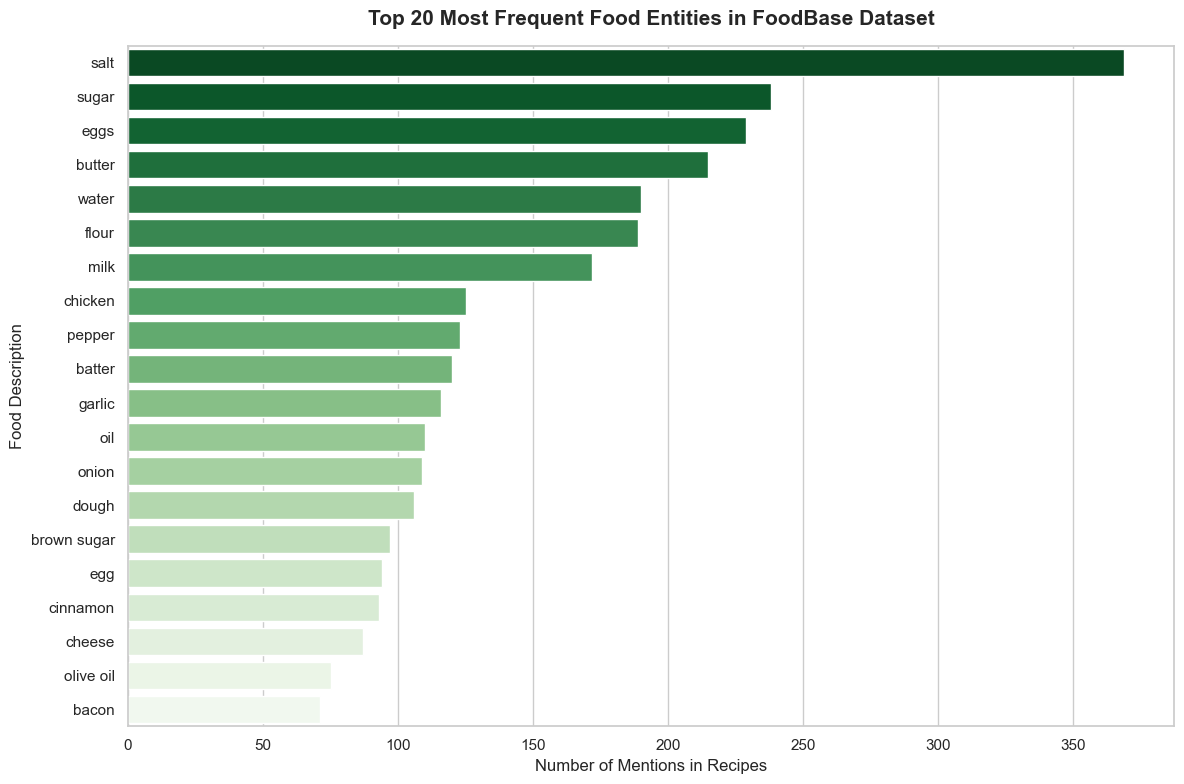

In [6]:
sns.set_theme(style="whitegrid")

f_names, f_counts = zip(*top_20_foods)
plt.figure(figsize=(12, 8))
sns.barplot(x=list(f_counts), y=list(f_names), palette="Greens_r")
plt.title("Top 20 Most Frequent Food Entities in FoodBase Dataset", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Number of Mentions in Recipes", fontsize=12)
plt.ylabel("Food Description", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Sample Sentences

In [7]:
print("Sample Sentences from FoodBase recipes:")
for idx, row in enumerate(rows[:5]):
    print(f"\n--- Recipe Sentence #{idx + 1} ---")
    formatted = []
    for t, l in zip(row['tokens'], row['labels']):
        if l != 'O':
            formatted.append(f"{t}[{l}]")
        else:
            formatted.append(t)
    print(" ".join(formatted))

Sample Sentences from FoodBase recipes:

--- Recipe Sentence #1 ---
Preheat oven to 375 degrees F ( 190 degrees C ) . Combine white[B-FOOD] rice[I-FOOD] flour[I-FOOD] , teff[B-FOOD] flour[I-FOOD] , cornstarch[B-FOOD] , sweet[B-FOOD] rice[I-FOOD] flour[I-FOOD] , baking[B-FOOD] soda[I-FOOD] , xanthan[B-FOOD] gum[I-FOOD] , and salt[B-FOOD] in a bowl . Beat butter[B-FOOD] , white[B-FOOD] sugar[I-FOOD] , brown[B-FOOD] sugar[I-FOOD] , and vanilla[B-FOOD] extract[I-FOOD] together in a bowl until smooth and creamy . Add eggs[B-FOOD] , 1 at a time , beating well after each addition . Slowly beat flour[B-FOOD] mixture[I-FOOD] into creamed[B-FOOD] butter[I-FOOD] mixture[I-FOOD] until dough[B-FOOD] is just mixed ; fold in chocolate[B-FOOD] chips[I-FOOD] and walnuts[B-FOOD] . Drop dough[B-FOOD] by round spoonful onto the baking sheet . Bake in the preheated oven until cookies[B-FOOD] are golden brown , 9 to 11 minutes . Let stand for 2 to 3 minutes on the baking sheet before transferring to a wire 